# データサイエンス講座(統計編)


In [1]:
import time
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
%matplotlib inline

## 2 代表値とは(実は色々ある平均の種類)

[代表値とは(実は色々ある平均の種類)【統計学入門②】 - 米国データサイエンティストのブログ](https://datawokagaku.com/rep_val/)

- 算術平均 (arithmetic mean): `numpy.mean()`
- 幾何平均 (geometric mean): `scipy.stats.gmean()`
- 調和平均 (harmonic mean): `scipy.stats.hmean()`

### 算術平均 (arithmetic mean)

In [2]:
apple_weights = [295, 300, 300, 310, 311]

In [3]:
def my_mean(x):
    return np.sum(x) / len(x)


my_mean(apple_weights)

np.float64(303.2)

In [4]:
np.mean(apple_weights)

np.float64(303.2)

### 幾何平均 (geometric mean)

In [5]:
a = np.arange(1, 101)
a

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [6]:
a.shape

(100,)

定義通りに計算

In [7]:
def my_gmean1(x):
    return np.prod(x) ** (1 / len(x))

In [8]:
my_gmean1(a)

np.float64(0.0)

In [9]:
a.prod()

np.int64(0)

総積の計算で桁があふれてしまう。一度対数に変換すると桁あふれが防げる。

In [10]:
def my_gmean2(x):
    return np.exp(np.mean(np.log(x)))

In [11]:
my_gmean2(a)

np.float64(37.992689344834304)

In [12]:
stats.gmean(a)

np.float64(37.992689344834304)

講座の例

In [13]:
salary_growth = [1.05, 1.1, 1.3]
my_gmean2(salary_growth)

np.float64(1.1450956868476592)

In [14]:
stats.gmean(salary_growth)

np.float64(1.1450956868476592)

### 調和平均(harmonic mean)

In [15]:
def my_hmean(x):
    return 1 / np.mean(1 / x)

In [16]:
velocities = np.array([20, 60])

In [17]:
my_hmean(velocities)

np.float64(30.0)

In [18]:
stats.hmean(velocities)

np.float64(30.0)

### 算術平均の重要な性質

- 偏差（算術平均からの差）の合計は0
- 算術平均は、各値からの差の平方和を最小にする値

In [19]:
deviations = apple_weights - np.mean(apple_weights)
deviations

array([-8.2, -3.2, -3.2,  6.8,  7.8])

In [20]:
np.sum(deviations)

np.float64(5.684341886080802e-14)

In [21]:
np.isclose(np.sum(deviations), 0)

np.True_

## 3 他にもある代表値(中央値と最頻値のポイント)

[他にもある代表値(中央値と最頻値のポイント)【統計学入門③】 - 米国データサイエンティストのブログ](https://datawokagaku.com/median_mode/)

- 中央値 (median): `numpy.median()`
- 最頻値 (mode): `scipy.stats.mode()` ←最頻値を **一つだけ** 返す（複峰でも）
    - 補足: pandas の `mode()` は **複数** 返す

### 中央値 (median)

ソートされた `ndarray` を `x_sorted`、`x_sorted` のサイズを `n` とする。

- `n` が奇数の場合: `x_sorted` の $(n - 1) / 2 (= \lfloor n /2 \rfloor)$ 番目の値
- `n` が偶数の場合: `x_sorted` の $n / 2 - 1$ 番目の値と $n / 2$ 番目の値の平均
- 補足: `ndarry` のインデックスは `0` から始まる
- 補足: $\lfloor \cdot \rfloor$ は床関数（小数点以下の切り捨て）

In [22]:
def my_median(x):
    x = np.sort(x)

    n = len(x)
    i = n // 2

    # 奇数サイズの場合
    if n % 2 == 1:
        return x[i]

    # 偶数サイズの場合
    return np.mean(x[i - 1 : i + 1])

偶数サイズの場合

In [23]:
a = np.array([1, 3, 2, 4, 5, 0])
my_median(a)

np.float64(2.5)

In [24]:
np.median(a)

np.float64(2.5)

奇数サイズの場合

In [25]:
a = np.array([1, 3, 2, 4, 0])
my_median(a)

np.int64(2)

In [26]:
np.median(a)

np.float64(2.0)

講座の例

標準正規分布から乱数抽出

In [27]:
rng = np.random.default_rng(1728)
randoms = rng.standard_normal(10**7)
randoms.size

10000000

平均の計算時間

In [28]:
before = time.time()
mean = np.mean(randoms)
after = time.time()
print(f"mean is {mean} (time:{after - before:.2f}s)")

mean is 0.0002448727273657092 (time:0.00s)


中央値の計算時間

In [29]:
before = time.time()
median = np.median(randoms)
after = time.time()
print(f"median is {median} (time:{after - before:.2f}s)")

median is 0.00013722580983493215 (time:0.09s)


### 最頻値 (mode)

In [30]:
def my_mode(x):
    u, counts = np.unique_counts(x)
    return (u[np.argmax(counts)], np.max(counts))

In [31]:
a = np.array([6, 2, 4, 5, 1, 3, 5, 3, 4])
my_mode(a)

(np.int64(3), np.int64(2))

In [32]:
stats.mode(a)

ModeResult(mode=np.int64(3), count=np.int64(2))

`3` 以外にも、`4`, `5` も2回出現するが、`scipy.stats.mode()` は `3` だけ返す。複峰については下記参照。

#### axis 引数

In [33]:
array = np.array([[1, 5, 3, 2], [4, 1, 3, 4], [7, 2, 1, 5], [5, 2, 4, 1]])
array

array([[1, 5, 3, 2],
       [4, 1, 3, 4],
       [7, 2, 1, 5],
       [5, 2, 4, 1]])

In [34]:
stats.mode(array, axis=0)

ModeResult(mode=array([1, 2, 3, 1]), count=array([1, 2, 2, 1]))

In [35]:
stats.mode(array, axis=1)

ModeResult(mode=array([1, 4, 1, 1]), count=array([1, 2, 1, 1]))

#### 補足: 複峰の場合

In [36]:
def my_mode_mm(x):
    u, counts = np.unique_counts(x)
    max_count = np.max(counts)
    return (u[counts == max_count], max_count)

In [37]:
a = np.array([6, 2, 4, 5, 1, 3, 5, 3, 4])
my_mode_mm(a)

(array([3, 4, 5]), np.int64(2))

In [38]:
pd.Series(a).mode()

0    3
1    4
2    5
dtype: int64

## 4 ばらつきを表す散布度(範囲と四分位数を使う)


[ばらつきを表す散布度(範囲と四分位数を使う)【統計学入門④】 - 米国データサイエンティストのブログ](https://datawokagaku.com/range_quartile/)

- 範囲 (range): `numpy.ptp()`（Peak to Peak の略）
- **分位数 (Quantile)**: `numpy.quantile(a, q)`
	- パーセンタイル (Percentile、1%刻み): `numpy.percentile(a, q)`
- **四分位範囲(interquartile range: IQR)**: `scipy.stats.iqr()`
- 四分位偏差(quartile deviation: QD)

### 範囲 (range)

In [39]:
def my_ptp(x):
    return np.max(x) - np.min(x)

In [40]:
dogs = np.array([10, 13, 17, 20, 29])
my_ptp(dogs)

np.int64(19)

In [41]:
np.ptp(dogs)

np.int64(19)

### 補足: 分位数 (quantile)

`x` は `ndarray`、`q` は確率（実数 $(0 \le q \le 1)$）とする。中央値と同様に、`x` をソートした配列を `y`、`y` のサイズを `n` とする。

`y` の $t = q \times (n - 1)$ 番目の値 `y[t]` を、**q分位数 (q-Quantile)** とする。これは、`y[0]` から `y[n-1]` までを、長さ $n - 1$ の線分に見立てて、$q : 1 - q$ で内分する点と考えると分かりやすい。

当然 $t$ は整数とは限らない。そこで、$t$ を

- $j = \lfloor t \rfloor$: `t` の整数部分
- $g = t - j$: `t` の小数部分

と分けて、次のように隣接する要素から補間して計算する。

$(1-g) \times y [j] + g \times y [j+1]$

補足: `q = 0.5` のとき、先ほどの中央値と等しくなる。

In [42]:
def my_quantile(x, q):
    y = np.sort(x)
    n = len(y)

    # 内分点
    t = q * (n - 1)

    j = int(t)  # 整数部分
    g = t - j  # 小数部分

    return (1 - g) * y[j] + g * y[j + 1]

In [43]:
a = np.arange(1, 7)
a

array([1, 2, 3, 4, 5, 6])

In [44]:
(my_quantile(a, 0.25), my_quantile(a, 0.5), my_quantile(a, 0.75))

(np.float64(2.25), np.float64(3.5), np.float64(4.75))

In [45]:
np.quantile(a, (0.25, 0.5, 0.75))

array([2.25, 3.5 , 4.75])

### 四分位範囲 (IQR) と四分位偏差 (QD)



In [46]:
def my_iqr(x):
    return np.quantile(x, 0.75) - np.quantile(x, 0.25)

四分位数

In [47]:
data = [33, 35, 36, 39, 43, 49, 51, 54, 54, 56, 62, 64, 64, 69, 70]
np.quantile(data, (0.25, 0.5, 0.75))

array([41., 54., 63.])

四分位範囲 (IQR)

In [48]:
my_iqr(data)

np.float64(22.0)

In [49]:
stats.iqr(data)

np.float64(22.0)

四分位偏差 (QD)

In [50]:
def my_qd(x):
    return stats.iqr(x) / 2

In [51]:
my_qd(data)

np.float64(11.0)

箱ひげ図 (Boxplot)

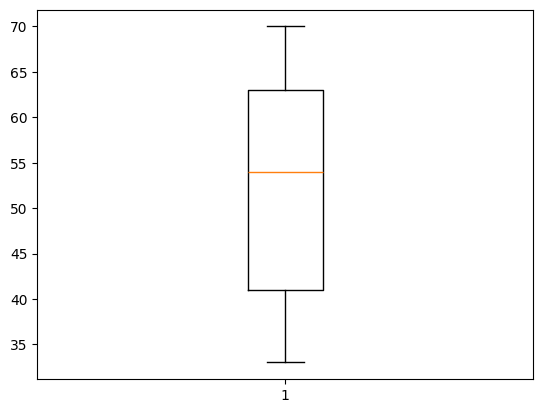

In [52]:
fig, axes = plt.subplots()
axes.boxplot(data)
plt.show()

## 5 絶対にわかる分散と標準偏差(超重要)

[絶対にわかる分散と標準偏差(超重要)【統計学入門⑤】 - 米国データサイエンティストのブログ](https://datawokagaku.com/var_std/)

- 平均偏差 MD
- 分散 $S^2$: `numpy.var(a, ddof=0)`
- 標準偏差 $S$: `numpy.std(a, ddof=0)`

### 平均偏差 (mean deviation)

MD = $\frac{1}{n} \sum_i | x_i - \overline{x} |$

In [53]:
def my_md(x):
    return np.sum(np.abs(x - np.mean(x))) / len(x)

In [54]:
samples = [10, 10, 11, 14, 15, 15, 16, 18, 18, 19, 20]
my_md(samples)

np.float64(2.826446280991735)

### 分散 (variance)

分散 $S^2 := \frac{1}{n} \sum_i ( x_i - \overline{x} )^2$

In [55]:
def my_var(x):
    return np.sum((x - np.mean(x)) ** 2) / len(x)

In [56]:
my_var(samples)

np.float64(11.537190082644628)

In [57]:
np.var(samples)

np.float64(11.537190082644628)

### 標準偏差 (standard deviation)

標準偏差 $S := \sqrt{S^2} = \sqrt{\frac{1}{n} \sum_i ( x_i - \overline{x} )^2}$

In [58]:
def my_std(x):
    return np.sqrt(np.var(x))

In [59]:
my_std(samples)

np.float64(3.3966439440489826)

In [60]:
np.std(samples)

np.float64(3.3966439440489826)

## 6 不偏分散ってなに？？なぜ標本分散は母集団分散より小さくなるのか

[不偏分散ってなに？？なぜ標本分散は母集団分散より小さくなるのか【統計学入門⑥】 - 米国データサイエンティストのブログ](https://datawokagaku.com/unbiased_variance/)

- 分散の期待値 $E(S^2)$ $\lt$ 母分散 $\sigma^2$
- 実験: 標本分布を見てみる
    - `numpy.random.Generator.choice(a, size=None)`: 標本抽出
- 数学的裏付け: 算術平均の性質
    - $\sum_i ( x_i - \overline{x} )^2 \le \sum_i ( x_i - \mu )^2$

母集団と母分散

In [61]:
population = np.array([1, 5, 10, 11, 14, 15, 15, 16, 18, 18, 19, 20, 25, 30])
np.var(population)

np.float64(51.392857142857146)

標本抽出

In [62]:
num_of_samples = 10_000
rng = np.random.default_rng(1728)
sample_vals = [np.var(rng.choice(population, size=3)) for _ in range(num_of_samples)]

標本分布

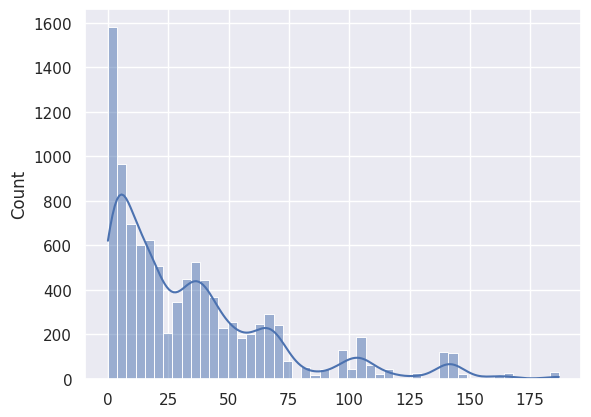

In [63]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(sample_vals, bins="auto", kde=True, ax=axes)
plt.show()

（標本）分散の平均

In [64]:
np.mean(sample_vals)

np.float64(34.40917777777778)

## 7 超わかりやすい！不偏分散がn-1で割る理由！不偏性とは

[超わかりやすい！不偏分散がn-1で割る理由！不偏性とは【統計学入門⑦】 - 米国データサイエンティストのブログ](https://datawokagaku.com/unbiased_estimator/)

### 実験: 標本平均の標本分布と平均

母集団と母平均

In [65]:
population = np.array([1, 5, 10, 11, 14, 15, 15, 16, 18, 18, 19, 20, 25, 30])
np.mean(population)

np.float64(15.5)

In [66]:
np.var(population)

np.float64(51.392857142857146)

#### サンプルサイズ 5

標本抽出

In [67]:
sample_size = 5
num_of_samples = 10_000
rng = np.random.default_rng(1728)
samples = [rng.choice(population, size=sample_size) for _ in range(num_of_samples)]

標本平均

In [68]:
samples_mean = [np.mean(sample) for sample in samples]

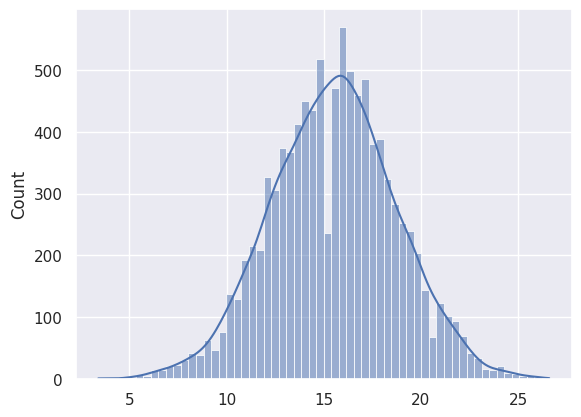

In [69]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(samples_mean, bins="auto", kde=True, ax=axes)
plt.show()

標本平均の平均

In [70]:
np.mean(samples_mean)

np.float64(15.513679999999999)

In [71]:
np.var(samples_mean)

np.float64(10.2560928576)

In [72]:
np.var(population) / sample_size

np.float64(10.278571428571428)

#### サンプルサイズ 10

In [73]:
sample_size = 10
num_of_samples = 10_000
rng = np.random.default_rng(1728)
samples = [rng.choice(population, size=sample_size) for _ in range(num_of_samples)]
samples_mean = [np.mean(sample) for sample in samples]

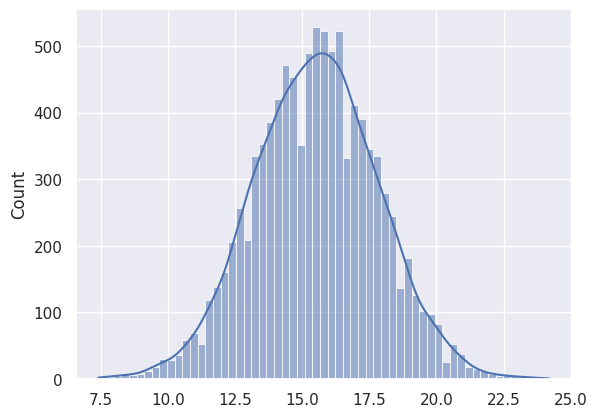

In [74]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(samples_mean, bins="auto", kde=True, ax=axes)
plt.show()

In [75]:
print(f"sample mean: {np.mean(samples_mean)}")
print(f"theoretical mean: {np.mean(population)}")
print(f"sample variance: {np.var(samples_mean)}")
print(f"theoretical variance: {np.var(population) / sample_size}")

sample mean: 15.512579999999998
theoretical mean: 15.5
sample variance: 5.2619737436
theoretical variance: 5.139285714285714


### 不偏分散 (variance)

不偏分散 $s^2 := \frac{1}{n-1} \sum_i ( x_i - \overline{x} )^2$

In [76]:
def my_unbiased_var(x):
    return np.sum((x - np.mean(x)) ** 2) / (len(x) - 1)

In [77]:
rng = np.random.default_rng(1728)
sample = rng.choice(population, size=3)
sample

array([ 5, 19, 14])

In [78]:
my_unbiased_var(sample)

np.float64(50.333333333333336)

In [79]:
np.var(sample, ddof=1)

np.float64(50.333333333333336)

In [80]:
stats.tvar(sample)

np.float64(50.333333333333336)

In [81]:
pd.Series(sample).var()

np.float64(50.333333333333336)

### （補足）実験: 不偏分散の標本分布と平均

In [82]:
sample_size = 3
num_of_samples = 10_000
rng = np.random.default_rng(1728)
samples = [rng.choice(population, size=sample_size) for _ in range(num_of_samples)]

In [83]:
samples_unbiased_var = [np.var(sample, ddof=1) for sample in samples]
np.mean(samples_unbiased_var)

np.float64(51.61376666666666)

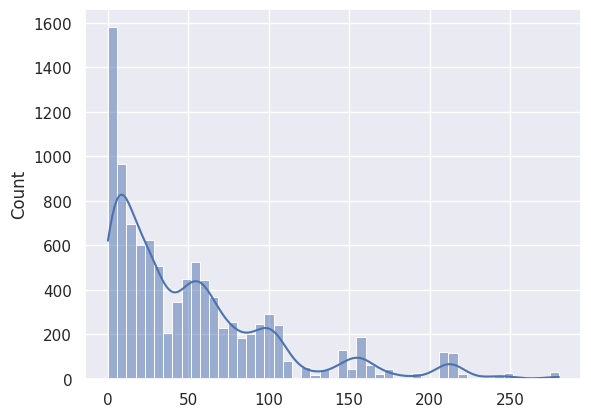

In [84]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(samples_unbiased_var, bins="auto", kde=True, ax=axes)
plt.show()

### 「不偏」標準偏差 (corrected sample standard deviation)

$s := \sqrt{s^2} = \sqrt{\frac{1}{n-1} \sum_i ( x_i - \overline{x} )^2}$

不偏分散 $s^2$ は母分散の不偏推定量であるが、この $s$ は母標準偏差の **不偏推定量ではない**。しかし、分散 $S^2$ から計算される標準偏差 $S$ と区別する為に、ここでは敢えて「不偏」標準偏差と呼ぶことにする。

In [85]:
def my_corrected_std(x):
    return np.sqrt(np.var(x, ddof=1))

In [86]:
rng = np.random.default_rng(1728)
sample = rng.choice(population, size=3)
sample

array([ 5, 19, 14])

In [87]:
my_corrected_std(sample)

np.float64(7.094598884597588)

In [88]:
np.std(sample, ddof=1)

np.float64(7.094598884597588)

In [89]:
stats.tstd(sample)

np.float64(7.094598884597588)

In [90]:
pd.Series(sample).std()

np.float64(7.094598884597588)

In [91]:
np.var(sample)

np.float64(33.55555555555556)

### 実験: 「不偏」標準偏差の標本分布

母集団の標準偏差

In [92]:
np.std(population)

np.float64(7.168881163951398)

「不偏」標準偏差 `s` の平均

In [93]:
samples_corrected_std = [np.std(sample, ddof=1) for sample in samples]
np.mean(samples_corrected_std)

np.float64(6.254145131582969)

標準偏差 `S` の平均

In [94]:
np.mean([np.std(sample, ddof=0) for sample in samples])

np.float64(5.106488116563278)

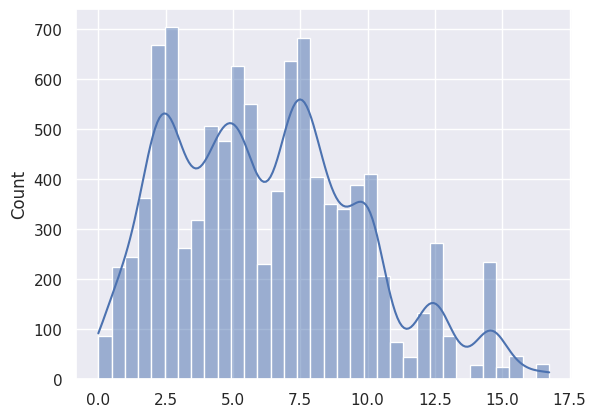

In [95]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(samples_corrected_std, bins="auto", kde=True, ax=axes)
plt.show()

## 8 標準偏差から散らばり具合をどう読み取る？

[標準偏差から散らばり具合をどう読み取る？【統計学入門⑧】 - 米国データサイエンティストのブログ](https://datawokagaku.com/std_distribution/)

標準偏差の範囲内に収まるデータの割合を、実験で確かめる。

- `numpy.random.Generator.normal()`: 正規分布に従う乱数生成
- `numpy.random.Generator.uniform()`: 連続一様分布に従う乱数生成
- **`scipy.stats.norm`: 正規分布の各種関数**
- **`scipy.stats.uniform`: 連続一様分布の各種関数**
- **`scipy.stats.rv_continuous`: 連続確率分布の基底クラス**
	- `cdf()`: 累積分布関数
	- `mean()`: 期待値
	- `std()`: 標準偏差

[Random Generator — NumPy Manual](https://numpy.org/doc/stable/reference/random/generator.html)

[rv_continuous — SciPy Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html)

### 実験: 標準正規分布

In [96]:
sample_size = 10_000
rng = np.random.default_rng(1728)
randoms = rng.normal(size=sample_size)

In [97]:
t_mean = stats.norm.mean()
t_std = stats.norm.std()

print(f"theoretical mean: {t_mean}")
print(f"sample mean: {np.mean(randoms)}")
print(f"theoretical SD: {t_std}")
print(f"sample SD: {np.std(randoms)}")

theoretical mean: 0.0
sample mean: 0.007775986045111138
theoretical SD: 1.0
sample SD: 1.005538212685025


#### 1シグマ

In [98]:
coef = 1
thresh = coef * t_std
range_low, range_high = t_mean - thresh, t_mean + thresh
np.count_nonzero((range_low < randoms) & (randoms < range_high)) / sample_size

np.float64(0.6793)

In [99]:
stats.norm.cdf(range_high) - stats.norm.cdf(range_low)

np.float64(0.6826894921370859)

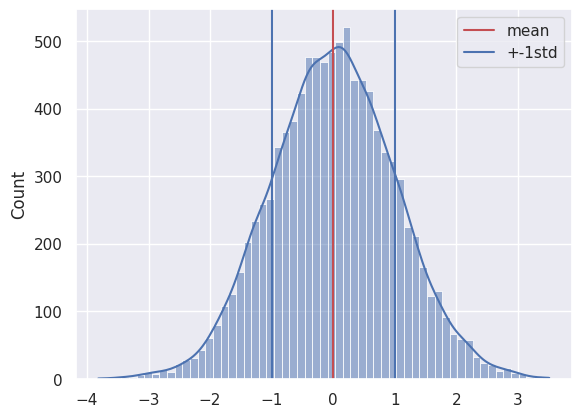

In [100]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(randoms, bins="auto", kde=True, ax=axes)
axes.axvline(t_mean, color="r", label="mean")
axes.axvline(range_low, color="b", label=f"+-{coef}std")
axes.axvline(range_high, color="b")
axes.legend()
plt.show()

#### 2シグマ

In [101]:
coef = 2
thresh = coef * t_std
range_low, range_high = t_mean - thresh, t_mean + thresh
np.count_nonzero((range_low < randoms) & (randoms < range_high)) / sample_size

np.float64(0.954)

In [102]:
stats.norm.cdf(range_high) - stats.norm.cdf(range_low)

np.float64(0.9544997361036416)

#### 3シグマ

In [103]:
coef = 3
thresh = coef * t_std
range_low, range_high = t_mean - thresh, t_mean + thresh
np.count_nonzero((range_low < randoms) & (randoms < range_high)) / sample_size

np.float64(0.9966)

In [104]:
stats.norm.cdf(range_high) - stats.norm.cdf(range_low)

np.float64(0.9973002039367398)

### 実験: 連続一様分布

In [105]:
rng = np.random.default_rng(1728)
randoms = rng.uniform(size=10_000)

In [106]:
t_mean = stats.uniform.mean()
t_std = stats.uniform.std()

print(f"theoretical mean: {t_mean}")
print(f"sample mean: {np.mean(randoms)}")
print(f"theoretical SD: {t_std}")
print(f"sample SD: {np.std(randoms)}")

theoretical mean: 0.5
sample mean: 0.5047497968727819
theoretical SD: 0.28867513459481287
sample SD: 0.28941943204801124


In [107]:
coef = 1
thresh = coef * t_std
range_low, range_high = t_mean - thresh, t_mean + thresh
np.count_nonzero((range_low < randoms) & (randoms < range_high)) / sample_size

np.float64(0.5775)

In [108]:
stats.uniform.cdf(range_high) - stats.uniform.cdf(range_low)

np.float64(0.5773502691896257)

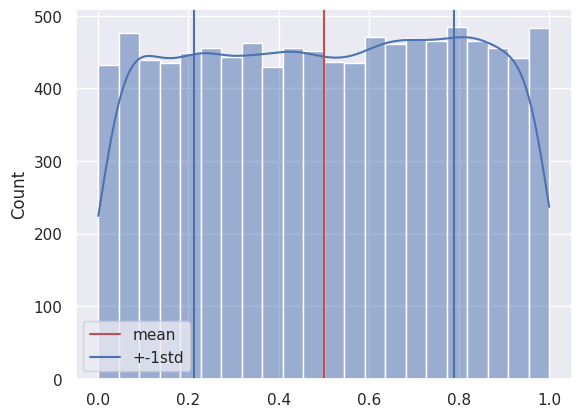

In [109]:
sns.set_theme()
fig, axes = plt.subplots()
sns.histplot(randoms, bins="auto", kde=True, ax=axes)
axes.axvline(t_mean, color="r", label="mean")
axes.axvline(range_low, color="b", label=f"+-{coef}std")
axes.axvline(range_high, color="b")
axes.legend()
plt.show()

### 補足: チェビシェフの不等式

$P(|X - \mu| \le k \sigma) \ge 1 - \frac{1}{k^2}$

In [110]:
# k = 2
1 - 1 / 2**2

0.75

In [111]:
# k = 3
1 - 1 / 3**2

0.8888888888888888

## 9 超重要！標準化と偏差値ってなに？？z得点とT得点

[超重要！標準化と偏差値ってなに？？z得点とT得点【統計学入門⑨】 - 米国データサイエンティストのブログ](https://datawokagaku.com/zscore/)

### z得点

$z = \frac{x - \overline{x}}{S}$


In [112]:
def my_zscore(x):
    return (x - np.mean(x)) / np.std(x)

データ

In [113]:
data = [0, 10, 20, 25, 27, 30, 43, 56, 68, 70]

標準化

In [114]:
z = my_zscore(data)
z

array([-1.54799532, -1.10444365, -0.66089199, -0.43911615, -0.35040582,
       -0.21734032,  0.35927685,  0.93589402,  1.46815602,  1.55686636])

平均と標準偏差

In [115]:
print(f"mean: {np.mean(z):.2f}")
print(f"std: {np.std(z):.2f}")

mean: 0.00
std: 1.00


In [116]:
stats.zscore(data)

array([-1.54799532, -1.10444365, -0.66089199, -0.43911615, -0.35040582,
       -0.21734032,  0.35927685,  0.93589402,  1.46815602,  1.55686636])

In [117]:
# StandardScalerインスタンス作成
scaler = StandardScaler()
# 標準化
scaler.fit_transform(np.expand_dims(data, axis=-1))

array([[-1.54799532],
       [-1.10444365],
       [-0.66089199],
       [-0.43911615],
       [-0.35040582],
       [-0.21734032],
       [ 0.35927685],
       [ 0.93589402],
       [ 1.46815602],
       [ 1.55686636]])

### 偏差値(T-score)

$T := 10z + 50 = 10 \frac{x - \overline{x}}{S} + 50$

In [118]:
def my_tscore(x):
    return 10 * stats.zscore(x) + 50

In [119]:
t = my_tscore(data)
t

array([34.52004677, 38.95556346, 43.39108014, 45.60883848, 46.49594182,
       47.82659682, 53.59276851, 59.3589402 , 64.68156023, 65.56866356])

In [120]:
print(f"mean: {np.mean(t):.2f}")
print(f"std: {np.std(t):.2f}")

mean: 50.00
std: 10.00
